# 📊 Notebook Didático — Preparação de Dados para Machine Learning

### Aplicação prática dos Módulos 2 a 17 da apostila *Engenharia e Preparação de Dados*

Este notebook aplica, passo a passo, as técnicas apresentadas na apostila utilizando um **dataset real**: o **Ames Housing Dataset** (`dados_imoveis.csv`), que contém informações sobre 1.459 imóveis residenciais, com 80 variáveis descrevendo características como área, qualidade, ano de construção, bairro, entre outras.

Esse dataset é ideal para fins didáticos porque reúne, em um único arquivo:

- variáveis **numéricas** (contínuas e discretas);
- variáveis **categóricas** (nominais e ordinais);
- **valores ausentes** reais, em diferentes proporções;
- variáveis com **outliers**;
- variáveis com diferentes **escalas**;
- exemplos naturais de **desbalanceamento** de classes.

> ⚠️ **Antes de começar:** certifique-se de que o arquivo `dados_imoveis.csv` está na mesma pasta deste notebook.



## 🔧 Configuração inicial

### Instalação das bibliotecas

Execute a célula abaixo **uma única vez** para instalar todas as bibliotecas utilizadas neste notebook. Caso já as tenha instaladas em seu ambiente, você pode pular esta etapa.

In [1]:
# Instalação das bibliotecas necessárias (execute apenas uma vez)
!pip install pandas numpy matplotlib seaborn scipy scikit-learn imbalanced-learn -q

Agora vamos importar as bibliotecas que utilizaremos ao longo de todo o notebook.

In [2]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística
from scipy import stats

# Machine Learning (pré-processamento e seleção de features)
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, LabelEncoder,
    MinMaxScaler, StandardScaler
)
from sklearn.feature_selection import SelectKBest, f_classif, f_regression, RFE
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


---
# 📁 Módulo 2 — Carregamento e Exploração de Dados CSV

Nesta seção, carregamos o arquivo CSV e realizamos a primeira exploração do conjunto de dados: dimensões, colunas, tipos, estatísticas descritivas e cardinalidade.

In [3]:
# Carregamento do dataset
df = pd.read_csv("dados_imoveis.csv", sep=",", encoding="utf-8")

print(f"O dataset foi carregado com sucesso!")
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")

O dataset foi carregado com sucesso!
Dimensões: 1459 linhas x 80 colunas


### 2.1 Primeira inspeção visual

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,...,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,...,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,...,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,...,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,...,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [5]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,...,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,...,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,...,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,...,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,80,32,0,0,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal
1458,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,2Story,7,5,1993,1994,Gable,CompShg,HdBoard,HdBoard,...,Typ,1,TA,Attchd,1993.0,Fin,3.0,650.0,TA,TA,Y,190,48,0,0,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal


### 2.2 Dimensões, colunas e tipos de dados

In [6]:
print("Formato (linhas, colunas):", df.shape)
print("\nNomes das colunas:")
print(df.columns.tolist())

Formato (linhas, colunas): (1459, 80)

Nomes das colunas:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'Enclos

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

In [8]:
df.dtypes.value_counts()

str        43
int64      26
float64    11
Name: count, dtype: int64

### 2.3 Estatísticas descritivas

`df.describe()` resume as variáveis **numéricas**. Para incluir também as **categóricas**, usamos `include="all"`.

In [9]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,1458.000000,1458.000000,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1457.000000,1457.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.00000,1381.000000,1458.000000,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,52.619342,554.294925,1046.117970,1156.534613,325.967786,3.543523,1486.045922,0.434454,0.065202,1.570939,0.377656,2.854010,1.042495,6.385195,0.58122,1977.721217,1.766118,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,176.753926,437.260486,442.898624,398.165820,420.610226,44.043251,485.566099,0.530648,0.252468,0.555190,0.503017,0.829788,0.208472,1.508895,0.64742,26.431175,0.775945,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,407.000000,0.000000,0.000000,407.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.00000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,0.000000,219.250000,784.000000,873.500000,0.000000,0.000000,1117.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.00000,1959.000000,1.000000,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,0.000000,460.000000,988.000000,1079.000000,0.000000,0.000000,1432.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,0.00000,1979.000000,2.000000,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,0.000000,797.750000,1305.000000,1382.500000,676.000000,0.000000,1721.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.00000,2002.000000,2.000000,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,1526.000000,2140.000000,5095.000000,5095.000000,1862.000000,1064.000000,5095.000000,3.000000,2.000000,4.000000,2.000000,6.000000,2.000000,15.000000,4.00000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [10]:
df.describe(include="all").T.head(15)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1459.0,NaN,NaN,NaN,2190.0,421.321334,1461.0,1825.5,2190.0,2554.5,2919.0
MSSubClass,1459.0,NaN,NaN,NaN,57.378341,42.74688,20.0,20.0,50.0,70.0,190.0
MSZoning,1455,5,RL,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,1232.0,NaN,NaN,NaN,68.580357,22.376841,21.0,58.0,67.0,80.0,200.0
LotArea,1459.0,NaN,NaN,NaN,9819.161069,4955.517327,1470.0,7391.0,9399.0,11517.5,56600.0
Street,1459,2,Pave,1453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley,107,2,Grvl,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotShape,1459,4,Reg,934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LandContour,1459,4,Lvl,1311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Utilities,1457,1,AllPub,1457,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.4 Cardinalidade e distribuição de classes

A cardinalidade indica quantos valores únicos existem em cada coluna — importante para decidir estratégias de codificação (Módulo 5).

In [11]:
cardinalidade = df.nunique().sort_values(ascending=False)
cardinalidade.head(15)

Id               1459
LotArea          1106
GrLivArea         879
BsmtUnfSF         793
1stFlrSF          789
TotalBsmtSF       736
BsmtFinSF1        669
GarageArea        459
2ndFlrSF          407
MasVnrArea        303
WoodDeckSF        263
OpenPorchSF       203
BsmtFinSF2        161
EnclosedPorch     131
LotFrontage       115
dtype: int64

In [ ]:
# Distribuição de uma variável categórica de interesse
df["Neighborhood"].value_counts()

> 💡 **Observação:** a coluna `Id` tem cardinalidade igual ao número de linhas — é um identificador único e **não deve ser usada como feature** para modelagem.

---
# 🧪 Módulo 3 — Qualidade dos Dados

Vamos investigar valores ausentes, duplicados e outros problemas comuns de qualidade.

### 3.1 Valores ausentes

O arquivo utiliza a string `"NA"` tanto para "não se aplica" (ex.: imóvel sem piscina) quanto, potencialmente, para dados realmente ausentes — algo comum em datasets reais e que exige atenção redobrada.

In [12]:
ausentes = df.isnull().sum()
ausentes_pct = (ausentes / len(df) * 100).round(2)

tabela_ausentes = pd.DataFrame({"qtd_ausentes": ausentes, "pct_ausentes": ausentes_pct})
tabela_ausentes = tabela_ausentes[tabela_ausentes["qtd_ausentes"] > 0].sort_values("qtd_ausentes", ascending=False)
tabela_ausentes

,qtd_ausentes,pct_ausentes
PoolQC,1456,99.79
MiscFeature,1408,96.50
Alley,1352,92.67
Fence,1169,80.12
MasVnrType,894,61.27
FireplaceQu,730,50.03
LotFrontage,227,15.56
GarageQual,78,5.35
GarageCond,78,5.35
GarageYrBlt,78,5.35


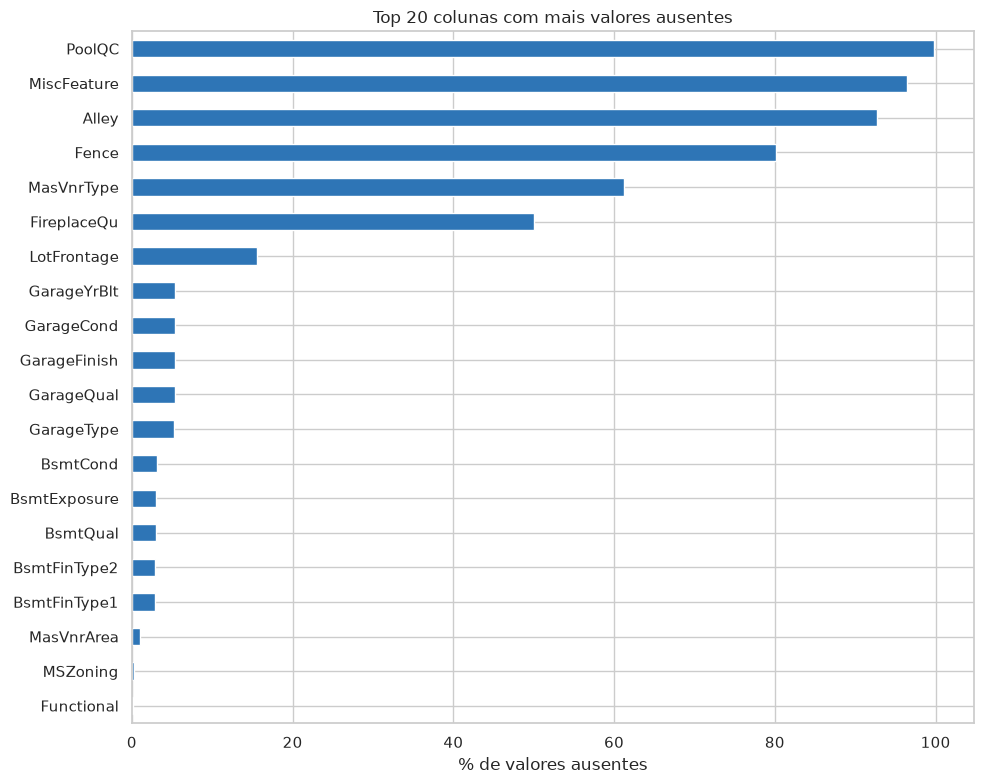

In [13]:
# Visualizando as colunas com mais valores ausentes
plt.figure(figsize=(10, 8))
tabela_ausentes["pct_ausentes"].head(20).sort_values().plot(kind="barh", color="#2E75B6")
plt.xlabel("% de valores ausentes")
plt.title("Top 20 colunas com mais valores ausentes")
plt.tight_layout()
plt.show()

> 💡 Colunas como `PoolQC`, `MiscFeature`, `Alley` e `Fence` têm altíssima proporção de ausência — nesses casos, o valor ausente provavelmente significa **"o imóvel não possui esse item"**, e não um erro de coleta. Trataremos isso no Módulo 4.

### 3.2 Dados duplicados

In [14]:
duplicados = df.duplicated().sum()
print(f"Número de linhas totalmente duplicadas: {duplicados}")

duplicados_sem_id = df.drop(columns=["Id"]).duplicated().sum()
print(f"Número de linhas duplicadas (ignorando o Id): {duplicados_sem_id}")

Número de linhas totalmente duplicadas: 0
Número de linhas duplicadas (ignorando o Id): 0


### 3.3 Valores inválidos / fora do domínio esperado

Uma boa prática é verificar se variáveis numéricas possuem valores fisicamente impossíveis (ex.: área negativa, ano de construção no futuro).

In [15]:
print("Ano de construção mínimo e máximo:", df["YearBuilt"].min(), "-", df["YearBuilt"].max())
print("Área do terreno (LotArea) mínima:", df["LotArea"].min())
print("Existem áreas negativas ou zero?", (df["LotArea"] <= 0).sum())

Ano de construção mínimo e máximo: 1879 - 2010
Área do terreno (LotArea) mínima: 1470
Existem áreas negativas ou zero? 0


### 3.4 Tipos incorretos

Vamos verificar se alguma coluna que deveria ser numérica foi carregada como texto (o que pode acontecer quando há símbolos ou valores como `"NA"` misturados).

In [16]:
# Colunas numéricas esperadas, mas carregadas como object, indicam possível problema de tipo
for col in df.columns:
    if df[col].dtype == "object":
        amostra = df[col].dropna().unique()[:5]
        # nada a corrigir aqui automaticamente — apenas inspeção
        pass

print("Total de colunas do tipo object (texto):", (df.dtypes == "object").sum())
print("Total de colunas numéricas:", df.select_dtypes(include=np.number).shape[1])

Total de colunas do tipo object (texto): 0
Total de colunas numéricas: 37


### 3.5 Tratamento inicial de valores ausentes (exemplo)

Vamos aplicar as três estratégias clássicas em colunas diferentes, apenas para fins didáticos (o tratamento definitivo será consolidado no Módulo 4).

In [17]:
# Exemplo: imputação pela mediana (variável numérica com poucos ausentes)
mediana_lotfrontage = df["LotFrontage"].median()
print("Mediana de LotFrontage:", mediana_lotfrontage)

# Exemplo: imputação pela moda (variável categórica com poucos ausentes)
moda_mszoning = df["MSZoning"].mode()[0]
print("Moda de MSZoning:", moda_mszoning)

# Exemplo: remoção de linhas (não recomendado aqui, apenas ilustrativo)
linhas_antes = df.shape[0]
linhas_sem_zoning_ausente = df.dropna(subset=["MSZoning"]).shape[0]
print(f"Linhas antes: {linhas_antes} | Linhas se removêssemos ausentes de MSZoning: {linhas_sem_zoning_ausente}")

Mediana de LotFrontage: 67.0
Moda de MSZoning: RL
Linhas antes: 1459 | Linhas se removêssemos ausentes de MSZoning: 1455


---
# 🧹 Módulo 4 — Limpeza e Padronização de Dados

Nesta seção, tratamos de forma consolidada os principais problemas identificados no Módulo 3, criando uma versão limpa do dataset (`df_limpo`).

### 4.1 Limpeza de strings

Vamos padronizar espaços e capitalização das colunas de texto.

In [18]:
df_limpo = df.copy()

colunas_texto = df_limpo.select_dtypes(include="object").columns

for col in colunas_texto:
    df_limpo[col] = df_limpo[col].astype(str).str.strip()

print("Espaços removidos das colunas de texto.")

Espaços removidos das colunas de texto.


/tmp/ipykernel_35898/2860225326.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df_limpo.select_dtypes(include="object").columns


### 4.2 Tratamento de valores ausentes por significado

Para as colunas em que `NA` representa **ausência do item** (e não dado faltante), substituímos por uma categoria explícita `"Nao_Possui"`. Para colunas numéricas relacionadas, substituímos por 0.

In [19]:
# Colunas categóricas em que NA significa "não possui o item"
colunas_na_significativo = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence", "MiscFeature", "MasVnrType"
]

for col in colunas_na_significativo:
    df_limpo[col] = df_limpo[col].replace("nan", np.nan)
    df_limpo[col] = df_limpo[col].fillna("Nao_Possui")

print("Valores ausentes com significado tratados como categoria explícita.")

Valores ausentes com significado tratados como categoria explícita.


In [20]:
# Colunas numéricas associadas a itens que podem não existir (ex.: área de garagem = 0 se não há garagem)
colunas_num_zero = ["MasVnrArea", "GarageYrBlt", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF"]

for col in colunas_num_zero:
    df_limpo[col] = df_limpo[col].fillna(0)

print("Valores ausentes numéricos (itens inexistentes) preenchidos com 0.")

Valores ausentes numéricos (itens inexistentes) preenchidos com 0.


### 4.3 Tratamento de valores realmente ausentes

Para colunas em que o valor ausente representa, de fato, dado faltante (não um "não se aplica"), aplicamos mediana (numéricas) ou moda (categóricas).

In [21]:
# Verificando o que ainda resta de ausente
ausentes_restantes = df_limpo.isnull().sum()
ausentes_restantes = ausentes_restantes[ausentes_restantes > 0].sort_values(ascending=False)
ausentes_restantes

LotFrontage     227
MSZoning          4
Utilities         2
BsmtFullBath      2
Functional        2
BsmtHalfBath      2
Exterior1st       1
Exterior2nd       1
KitchenQual       1
GarageCars        1
GarageArea        1
SaleType          1
dtype: int64

In [22]:
for col in ausentes_restantes.index:
    if df_limpo[col].dtype in [np.float64, np.int64]:
        valor = df_limpo[col].median()
        df_limpo[col] = df_limpo[col].fillna(valor)
    else:
        valor = df_limpo[col].mode()[0]
        df_limpo[col] = df_limpo[col].fillna(valor)

print("Valores ausentes remanescentes tratados com mediana/moda.")
print("Total de valores ausentes após o tratamento:", df_limpo.isnull().sum().sum())

Valores ausentes remanescentes tratados com mediana/moda.
Total de valores ausentes após o tratamento: 0


### 4.4 Padronização de categorias

Vamos garantir que valores textuais equivalentes estejam escritos de forma consistente (letras minúsculas, sem espaços extras).

In [23]:
df_limpo["Neighborhood"] = df_limpo["Neighborhood"].str.strip().str.title()
df_limpo["Neighborhood"].unique()[:10]

<StringArray>
[  'Names', 'Gilbert', 'Stonebr',  'Brdale', 'Npkvill', 'Nridght', 'Blmngtn',
 'Noridge', 'Somerst', 'Sawyerw']
Length: 10, dtype: str

### 4.5 Conversão de tipos

A coluna `MSSubClass` representa, na verdade, um **código categórico** (classe do imóvel), embora esteja armazenada como número. Vamos convertê-la para string, evitando que seja tratada erroneamente como variável numérica contínua.

In [24]:
df_limpo["MSSubClass"] = df_limpo["MSSubClass"].astype(str)
print(df_limpo["MSSubClass"].dtype)
df_limpo["MSSubClass"].value_counts().head()

str


MSSubClass
20     543
60     276
50     143
120     95
30      70
Name: count, dtype: int64

> ✅ A partir daqui, utilizaremos `df_limpo` como base para os próximos módulos.

---
# 🏷️ Módulo 5 — Variáveis Categóricas

Vamos identificar variáveis nominais e ordinais e aplicar as técnicas de codificação apropriadas para cada uma.

### 5.1 Identificando variáveis nominais e ordinais

- **Nominal:** `Neighborhood` (bairro) — não existe ordem entre as categorias.
- **Ordinal:** `ExterQual` (qualidade do acabamento externo) — possui uma ordem lógica de qualidade: `Po < Fa < TA < Gd < Ex`.

In [25]:
print("Categorias de Neighborhood (nominal):", df_limpo["Neighborhood"].nunique())
print("Categorias de ExterQual (ordinal):", df_limpo["ExterQual"].unique())

Categorias de Neighborhood (nominal): 25
Categorias de ExterQual (ordinal): <StringArray>
['TA', 'Gd', 'Ex', 'Fa']
Length: 4, dtype: str


### 5.2 Ordinal Encoding

Para `ExterQual`, respeitamos a ordem lógica das categorias ao codificá-las.

In [26]:
ordem_qualidade = ["Po", "Fa", "TA", "Gd", "Ex"]

encoder_ordinal = OrdinalEncoder(categories=[ordem_qualidade])
df_limpo["ExterQual_encoded"] = encoder_ordinal.fit_transform(df_limpo[["ExterQual"]])

df_limpo[["ExterQual", "ExterQual_encoded"]].drop_duplicates().sort_values("ExterQual_encoded")

,ExterQual,ExterQual_encoded
96,Fa,1.0
0,TA,2.0
4,Gd,3.0
15,Ex,4.0


### 5.3 Label Encoding

Aplicado, por exemplo, a variáveis binárias como `CentralAir` (Sim/Não), em que a codificação numérica não introduz uma falsa relação de ordem.

In [27]:
label_encoder = LabelEncoder()
df_limpo["CentralAir_encoded"] = label_encoder.fit_transform(df_limpo["CentralAir"])

df_limpo[["CentralAir", "CentralAir_encoded"]].drop_duplicates()

,CentralAir,CentralAir_encoded
0,Y,1
31,N,0


### 5.4 One-Hot Encoding

Para variáveis **nominais** com poucas categorias, como `Street` (tipo de acesso à rua), o One-Hot Encoding é a técnica mais adequada, pois não introduz relação de ordem.

In [28]:
df_onehot = pd.get_dummies(df_limpo, columns=["Street"], prefix="Street")
df_onehot[[c for c in df_onehot.columns if "Street" in c]].head()

,Street_Grvl,Street_Pave
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True


### 5.5 Alta cardinalidade

`Neighborhood` possui muitas categorias distintas — aplicar One-Hot Encoding diretamente geraria dezenas de novas colunas.

In [29]:
print(f"Neighborhood possui {df_limpo['Neighborhood'].nunique()} categorias distintas.")

# Se aplicássemos One-Hot Encoding diretamente:
colunas_geradas = pd.get_dummies(df_limpo["Neighborhood"]).shape[1]
print(f"One-Hot Encoding geraria {colunas_geradas} novas colunas — alta cardinalidade!")

Neighborhood possui 25 categorias distintas.
One-Hot Encoding geraria 25 novas colunas — alta cardinalidade!


Uma estratégia comum é agrupar categorias raras em `"Outros"` antes de aplicar o One-Hot Encoding.

In [30]:
frequencia = df_limpo["Neighborhood"].value_counts()
categorias_frequentes = frequencia[frequencia >= 30].index

df_limpo["Neighborhood_agrupado"] = df_limpo["Neighborhood"].apply(
    lambda x: x if x in categorias_frequentes else "Outros"
)

print(f"Categorias após agrupamento: {df_limpo['Neighborhood_agrupado'].nunique()}")
df_limpo["Neighborhood_agrupado"].value_counts()

Categorias após agrupamento: 17


Neighborhood_agrupado
Names      218
Outros     145
Oldtown    126
Collgcr    117
Somerst     96
Edwards     94
Nridght     89
Gilbert     86
Sawyer      77
Sawyerw     66
Mitchel     65
Nwames      58
Idotrr      56
Crawfor     52
Brkside     50
Timber      34
Noridge     30
Name: count, dtype: int64

---
# 🔢 Módulo 6 — Variáveis Numéricas

Vamos calcular as principais medidas de tendência central e dispersão para variáveis numéricas relevantes.

In [31]:
variaveis_numericas = ["LotArea", "GrLivArea", "OverallQual", "YearBuilt", "TotalBsmtSF"]

resumo = pd.DataFrame({
    "media": df_limpo[variaveis_numericas].mean(),
    "mediana": df_limpo[variaveis_numericas].median(),
    "moda": df_limpo[variaveis_numericas].mode().iloc[0],
    "variancia": df_limpo[variaveis_numericas].var(),
    "desvio_padrao": df_limpo[variaveis_numericas].std(),
    "amplitude": df_limpo[variaveis_numericas].max() - df_limpo[variaveis_numericas].min(),
})
resumo.round(2)

,media,mediana,moda,variancia,desvio_padrao,amplitude
LotArea,9819.16,9399.0,9600.0,24557151.98,4955.52,55130.0
GrLivArea,1486.05,1432.0,864.0,235774.44,485.57,4688.0
OverallQual,6.08,6.0,5.0,2.06,1.44,9.0
YearBuilt,1971.36,1973.0,2005.0,923.56,30.39,131.0
TotalBsmtSF,1045.40,988.0,0.0,196774.73,443.59,5095.0


### 6.1 Quartis e percentis

In [32]:
df_limpo["GrLivArea"].quantile([0.25, 0.5, 0.75])

0.25    1117.5
0.50    1432.0
0.75    1721.0
Name: GrLivArea, dtype: float64

In [33]:
# Percentis customizados
df_limpo["GrLivArea"].quantile([0.05, 0.10, 0.90, 0.95])

0.05     864.0
0.10     936.0
0.90    2134.4
0.95    2461.3
Name: GrLivArea, dtype: float64

### 6.2 Discreta vs. contínua

- `OverallQual` (nota de qualidade de 1 a 10) é uma variável **discreta**.
- `GrLivArea` (área construída em pés²) é uma variável **contínua**.

In [34]:
print("Valores únicos de OverallQual (discreta):", sorted(df_limpo['OverallQual'].unique()))
print("\nGrLivArea (contínua) — min:", df_limpo['GrLivArea'].min(), "| max:", df_limpo['GrLivArea'].max())

Valores únicos de OverallQual (discreta): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

GrLivArea (contínua) — min: 407 | max: 5095


> 💡 **Interpretação:** compare a média e a mediana de `GrLivArea` — se forem muito diferentes, isso é um indício de assimetria na distribuição (veremos isso formalmente no Módulo 8).

In [35]:
print("Média de GrLivArea:", df_limpo["GrLivArea"].mean().round(2))
print("Mediana de GrLivArea:", df_limpo["GrLivArea"].median())

Média de GrLivArea: 1486.05
Mediana de GrLivArea: 1432.0


---
# 📈 Módulo 7 — Outliers

Vamos detectar outliers na variável `GrLivArea` (área construída) usando os métodos IQR e Z-score, e discutir estratégias de tratamento.

### 7.1 Detecção visual com boxplot

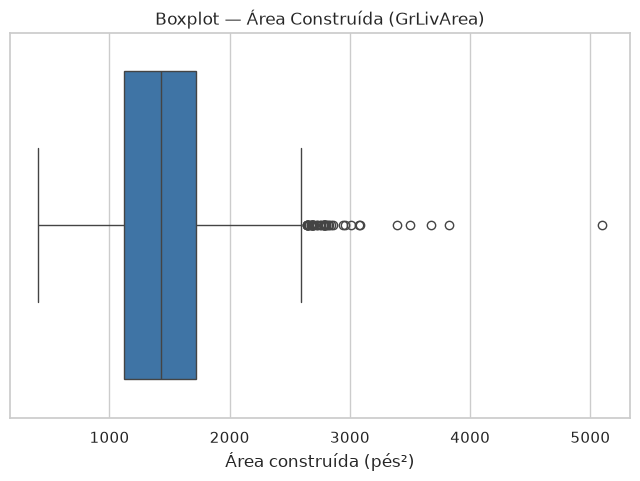

In [36]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_limpo["GrLivArea"], color="#2E75B6")
plt.title("Boxplot — Área Construída (GrLivArea)")
plt.xlabel("Área construída (pés²)")
plt.show()

### 7.2 Método IQR (Intervalo Interquartil)

In [37]:
Q1 = df_limpo["GrLivArea"].quantile(0.25)
Q3 = df_limpo["GrLivArea"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_iqr = df_limpo[(df_limpo["GrLivArea"] < limite_inferior) | (df_limpo["GrLivArea"] > limite_superior)]

print(f"Q1 = {Q1} | Q3 = {Q3} | IQR = {IQR}")
print(f"Limite inferior: {limite_inferior:.2f} | Limite superior: {limite_superior:.2f}")
print(f"Número de outliers detectados (IQR): {len(outliers_iqr)}")

Q1 = 1117.5 | Q3 = 1721.0 | IQR = 603.5
Limite inferior: 212.25 | Limite superior: 2626.25
Número de outliers detectados (IQR): 44


### 7.3 Método Z-score

In [38]:
df_limpo["zscore_GrLivArea"] = np.abs(stats.zscore(df_limpo["GrLivArea"]))
outliers_zscore = df_limpo[df_limpo["zscore_GrLivArea"] > 3]

print(f"Número de outliers detectados (Z-score > 3): {len(outliers_zscore)}")
outliers_zscore[["GrLivArea", "zscore_GrLivArea"]].sort_values("zscore_GrLivArea", ascending=False).head()

Número de outliers detectados (Z-score > 3): 10


,GrLivArea,zscore_GrLivArea
1089,5095,7.435016
728,3820,4.808314
1362,3672,4.503411
1222,3500,4.149064
1168,3390,3.922446


### 7.4 Discussão sobre o tratamento

Vamos observar os imóveis identificados como outliers: eles podem representar **casas legítimas, porém excepcionalmente grandes** — não necessariamente um erro de digitação.

In [39]:
outliers_iqr[["GrLivArea", "OverallQual", "Neighborhood", "YearBuilt"]].sort_values("GrLivArea", ascending=False).head(10)

,GrLivArea,OverallQual,Neighborhood,YearBuilt
1089,5095,10,Edwards,2008
728,3820,5,Edwards,1959
1362,3672,6,Edwards,1935
1222,3500,9,Noridge,1993
1168,3390,10,Stonebr,2006
964,3086,5,Names,1935
871,3078,9,Noridge,1998
278,3005,7,Somerst,2004
838,2956,8,Nridght,2004
579,2944,9,Veenker,1977


> ⚠️ **Nem todo outlier deve ser removido.** Neste caso, os imóveis com área muito grande costumam ter também nota de qualidade elevada — são mansões reais, não erros. A decisão de remover, limitar (capping) ou manter deve considerar o contexto do problema.

Como exemplo, aplicamos abaixo a técnica de **limitação (capping)**, apenas para fins ilustrativos:

In [40]:
df_capping = df_limpo.copy()
df_capping["GrLivArea_capped"] = df_capping["GrLivArea"].clip(lower=limite_inferior, upper=limite_superior)

print("Máximo antes do capping:", df_capping["GrLivArea"].max())
print("Máximo depois do capping:", df_capping["GrLivArea_capped"].max())

Máximo antes do capping: 5095
Máximo depois do capping: 2626.25


---
# 📐 Módulo 8 — Análise Estatística Exploratória (EDA)

Vamos calcular um conjunto completo de medidas estatísticas — incluindo assimetria e curtose — para compreender melhor a distribuição das variáveis numéricas.

In [ ]:
def resumo_estatistico(serie):
    return pd.Series({
        "média": serie.mean(),
        "mediana": serie.median(),
        "desvio_padrão": serie.std(),
        "variância": serie.var(),
        "Q1": serie.quantile(0.25),
        "Q3": serie.quantile(0.75),
        "assimetria": serie.skew(),
        "curtose": serie.kurtosis(),
    })

resumo_estatistico(df_limpo["GrLivArea"]).round(2)

In [ ]:
resumo_estatistico(df_limpo["SalePrice"] if "SalePrice" in df_limpo.columns else df_limpo["GrLivArea"]).round(2)

### 8.1 Interpretando a assimetria (skewness)

- **Assimetria ≈ 0:** distribuição aproximadamente simétrica.
- **Assimetria > 0:** cauda mais longa à direita (valores altos mais dispersos).
- **Assimetria < 0:** cauda mais longa à esquerda.

In [ ]:
variaveis = ["GrLivArea", "LotArea", "OverallQual", "YearBuilt"]

tabela_assimetria = pd.DataFrame({
    "assimetria": df_limpo[variaveis].skew(),
    "curtose": df_limpo[variaveis].kurtosis()
}).round(2)

tabela_assimetria

> 💡 `LotArea` costuma apresentar assimetria positiva alta — poucos terrenos muito grandes distorcem a distribuição. Isso motivará a transformação logarítmica no Módulo 14.

---
# 📊 Módulo 9 — Histogramas e Distribuições

Vamos visualizar a distribuição de diferentes variáveis e identificar seus formatos (normal, assimétrica, bimodal, uniforme).

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df_limpo["GrLivArea"], bins=30, kde=True, ax=axes[0, 0], color="#2E75B6")
axes[0, 0].set_title("GrLivArea — assimétrica à direita")

sns.histplot(df_limpo["YearBuilt"], bins=30, kde=True, ax=axes[0, 1], color="#548235")
axes[0, 1].set_title("YearBuilt — distribuição do ano de construção")

sns.histplot(df_limpo["OverallQual"], bins=10, kde=False, ax=axes[1, 0], color="#BF8F00")
axes[1, 0].set_title("OverallQual — variável discreta (aprox. normal)")

sns.histplot(df_limpo["LotArea"], bins=40, kde=True, ax=axes[1, 1], color="#C00000")
axes[1, 1].set_title("LotArea — forte assimetria positiva")

plt.tight_layout()
plt.show()

### 9.1 Interpretação

- `GrLivArea` e `LotArea`: distribuições **assimétricas à direita** — a maioria dos imóveis tem área moderada, mas alguns poucos têm área muito grande.
- `YearBuilt`: apresenta múltiplos picos, sugerindo **ciclos de construção** ao longo das décadas (padrão próximo de multimodal).
- `OverallQual`: por ser discreta e concentrada entre 4 e 8, se aproxima de uma distribuição **aproximadamente normal**.

---
# 🎲 Módulo 10 — Probabilidade

Vamos aplicar os conceitos fundamentais de probabilidade a eventos definidos sobre o próprio dataset.

### 10.1 Espaço amostral e eventos

Considere o experimento: **sortear aleatoriamente um imóvel do dataset**. O espaço amostral é o conjunto de todos os 1.459 imóveis.

Vamos definir dois eventos:
- **A:** o imóvel possui ar-condicionado central (`CentralAir == "Y"`)
- **B:** o imóvel foi construído após o ano 2000 (`YearBuilt > 2000`)

In [ ]:
total_imoveis = len(df_limpo)

evento_A = df_limpo["CentralAir"] == "Y"
evento_B = df_limpo["YearBuilt"] > 2000

P_A = evento_A.sum() / total_imoveis
P_B = evento_B.sum() / total_imoveis

print(f"P(A) = P(possui ar-condicionado central) = {P_A:.4f}")
print(f"P(B) = P(construído após 2000) = {P_B:.4f}")

### 10.2 Probabilidade conjunta P(A ∩ B)

In [ ]:
P_A_e_B = (evento_A & evento_B).sum() / total_imoveis
print(f"P(A ∩ B) = P(possui ar-condicionado E foi construído após 2000) = {P_A_e_B:.4f}")

### 10.3 Probabilidade condicional P(A | B)

"Dado que o imóvel foi construído após 2000, qual a probabilidade de possuir ar-condicionado central?"


In [ ]:
P_A_dado_B = (evento_A & evento_B).sum() / evento_B.sum()
print(f"P(A | B) = {P_A_dado_B:.4f}")
print(f"Compare com P(A) = {P_A:.4f} (probabilidade sem a condição)")

> 💡 Se `P(A | B)` for muito maior que `P(A)`, isso sugere que **imóveis mais novos têm maior chance de possuir ar-condicionado central** — um indício de associação entre as variáveis, que investigaremos formalmente no Módulo 11.

### 10.4 Verificando independência

Dois eventos são independentes quando `P(A ∩ B) = P(A) × P(B)`.

In [ ]:
produto_marginal = P_A * P_B

print(f"P(A) x P(B) = {produto_marginal:.4f}")
print(f"P(A ∩ B) observado = {P_A_e_B:.4f}")

if abs(produto_marginal - P_A_e_B) < 0.01:
    print("Os eventos parecem aproximadamente independentes.")
else:
    print("Os eventos NÃO parecem independentes — há indícios de associação.")

---
# 🔗 Módulo 11 — Probabilidade Conjunta e Tabelas de Contingência

Vamos formalizar a investigação de associação entre variáveis categóricas usando tabelas de contingência.

### 11.1 Construindo a tabela de contingência

Vamos investigar a relação entre `CentralAir` (ar-condicionado central) e uma versão categorizada do ano de construção.

In [ ]:
df_limpo["Epoca_Construcao"] = pd.cut(
    df_limpo["YearBuilt"],
    bins=[1870, 1950, 1980, 2000, 2011],
    labels=["Ate_1950", "1951_1980", "1981_2000", "Apos_2000"]
)

tabela_contingencia = pd.crosstab(df_limpo["Epoca_Construcao"], df_limpo["CentralAir"])
tabela_contingencia

### 11.2 Convertendo em probabilidades

In [ ]:
# Probabilidade conjunta
tabela_conjunta = pd.crosstab(df_limpo["Epoca_Construcao"], df_limpo["CentralAir"], normalize="all")
print("Probabilidade conjunta P(Época ∩ CentralAir):")
tabela_conjunta.round(3)

In [ ]:
# Probabilidade condicional: P(CentralAir | Época)
tabela_condicional = pd.crosstab(df_limpo["Epoca_Construcao"], df_limpo["CentralAir"], normalize="index")
print("Probabilidade condicional P(CentralAir | Época):")
tabela_condicional.round(3)

### 11.3 Probabilidades marginais

In [ ]:
marginais_epoca = tabela_conjunta.sum(axis=1)
marginais_central_air = tabela_conjunta.sum(axis=0)

print("Probabilidade marginal por época:")
print(marginais_epoca.round(3))
print("\nProbabilidade marginal por CentralAir:")
print(marginais_central_air.round(3))

### 11.4 Visualizando a associação

In [ ]:
tabela_condicional.plot(kind="bar", stacked=True, figsize=(9, 5), color=["#C00000", "#2E75B6"])
plt.title("Proporção de imóveis com/sem ar-condicionado central, por época de construção")
plt.ylabel("Proporção")
plt.xlabel("Época de construção")
plt.legend(title="CentralAir", bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> 💡 **Interpretação:** observe como a proporção de imóveis com ar-condicionado central cresce nas construções mais recentes — um forte indício de associação entre as duas variáveis, confirmando a intuição do Módulo 10.

---
# 🔄 Módulo 12 — Correlação

Vamos investigar a correlação entre variáveis numéricas, usando os coeficientes de Pearson e Spearman.

### 12.1 Matriz de correlação (Pearson)

In [ ]:
variaveis_interesse = [
    "LotArea", "OverallQual", "OverallCond", "YearBuilt", "TotalBsmtSF",
    "GrLivArea", "FullBath", "GarageCars", "GarageArea"
]

matriz_corr = df_limpo[variaveis_interesse].corr(method="pearson")
matriz_corr.round(2)

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", center=0, linewidths=0.5)
plt.title("Matriz de Correlação de Pearson")
plt.tight_layout()
plt.show()

### 12.2 Correlação de Spearman

Mais robusta a outliers e capaz de capturar relações monotônicas não necessariamente lineares.

In [ ]:
matriz_corr_spearman = df_limpo[variaveis_interesse].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr_spearman, annot=True, cmap="coolwarm", fmt=".2f", center=0, linewidths=0.5)
plt.title("Matriz de Correlação de Spearman")
plt.tight_layout()
plt.show()

### 12.3 Identificando as correlações mais fortes

In [ ]:
corr_pares = matriz_corr.unstack().sort_values(ascending=False)
corr_pares = corr_pares[corr_pares < 1.0]  # remove a diagonal (correlação de uma variável com ela mesma)
corr_pares.drop_duplicates().head(10)

> ⚠️ **Correlação não implica causalidade.** `GarageCars` e `GarageArea` são fortemente correlacionadas — o que é esperado, já que garagens maiores comportam mais carros. Mas isso não significa que uma "causa" a outra: ambas refletem o mesmo atributo estrutural do imóvel (tamanho da garagem).

---
# 🖼️ Módulo 13 — Visualização de Dados

Vamos aplicar os principais tipos de gráficos apresentados na apostila para explorar visualmente o dataset.

### 13.1 Histograma

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_limpo["GrLivArea"], bins=30, kde=True, color="#2E75B6")
plt.title("Histograma — Área construída (GrLivArea)")
plt.xlabel("Área construída (pés²)")
plt.show()

### 13.2 Boxplot (comparando grupos)

In [ ]:
plt.figure(figsize=(10, 6))
ordem = sorted(df_limpo["OverallQual"].unique())
sns.boxplot(x="OverallQual", y="GrLivArea", data=df_limpo, order=ordem, palette="Blues")
plt.title("Área construída por nota de qualidade geral (OverallQual)")
plt.xlabel("Qualidade geral (1-10)")
plt.ylabel("Área construída (pés²)")
plt.show()

### 13.3 Gráfico de dispersão (scatter plot)

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="GrLivArea", y="TotalBsmtSF", hue="OverallQual", data=df_limpo, palette="viridis", alpha=0.7)
plt.title("Relação entre área construída e área do porão")
plt.xlabel("Área construída (pés²)")
plt.ylabel("Área do porão (pés²)")
plt.legend(title="Qualidade", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

### 13.4 Gráfico de barras

In [ ]:
plt.figure(figsize=(11, 5))
df_limpo["Neighborhood_agrupado"].value_counts().plot(kind="bar", color="#548235")
plt.title("Número de imóveis por bairro (agrupado)")
plt.xlabel("Bairro")
plt.ylabel("Quantidade de imóveis")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

### 13.5 Gráfico de linhas (tendência ao longo do tempo)

In [ ]:
imoveis_por_ano = df_limpo.groupby("YearBuilt").size()

plt.figure(figsize=(11, 5))
imoveis_por_ano.plot(kind="line", color="#C00000")
plt.title("Número de imóveis construídos por ano")
plt.xlabel("Ano de construção")
plt.ylabel("Quantidade de imóveis")
plt.show()

### 13.6 Heatmap

Já construído no Módulo 12 (matriz de correlação) — reforça como o heatmap é a ferramenta ideal para visualizar relações entre múltiplas variáveis numéricas de uma só vez.

### 13.7 Pairplot

In [ ]:
subset_pairplot = df_limpo[["GrLivArea", "TotalBsmtSF", "OverallQual", "YearBuilt"]].sample(300, random_state=42)

sns.pairplot(subset_pairplot, diag_kind="kde", plot_kws={"alpha": 0.5, "color": "#2E75B6"})
plt.suptitle("Pairplot de variáveis numéricas selecionadas", y=1.02)
plt.show()

> 💡 Usamos uma amostra de 300 linhas para o pairplot por questões de desempenho — com datasets maiores, gerar o gráfico completo pode ser lento.

---
# 🛠️ Módulo 14 — Engenharia de Features

Vamos criar novas variáveis (features) a partir das colunas existentes, aplicando as técnicas apresentadas na apostila.

### 14.1 Discretização (binning)

Transformando `OverallQual` (nota numérica) em uma faixa categórica.

In [ ]:
df_limpo["Faixa_Qualidade"] = pd.cut(
    df_limpo["OverallQual"],
    bins=[0, 3, 6, 8, 10],
    labels=["Baixa", "Media", "Boa", "Excelente"]
)

df_limpo[["OverallQual", "Faixa_Qualidade"]].drop_duplicates().sort_values("OverallQual")

### 14.2 Features temporais

Vamos criar variáveis derivadas de `YearBuilt` e `YrSold`.

In [ ]:
df_limpo["Idade_Imovel"] = df_limpo["YrSold"] - df_limpo["YearBuilt"]
df_limpo["Foi_Reformado"] = (df_limpo["YearRemodAdd"] != df_limpo["YearBuilt"]).astype(int)
df_limpo["Anos_Desde_Reforma"] = df_limpo["YrSold"] - df_limpo["YearRemodAdd"]

df_limpo[["YearBuilt", "YrSold", "Idade_Imovel", "Foi_Reformado", "Anos_Desde_Reforma"]].head()

### 14.3 Transformação logarítmica

Reduz a assimetria de variáveis com distribuição enviesada, como `LotArea` (vista no Módulo 8/9).

In [ ]:
df_limpo["LotArea_log"] = np.log1p(df_limpo["LotArea"])  # log1p evita problemas com valores zero

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_limpo["LotArea"], bins=40, ax=axes[0], color="#C00000")
axes[0].set_title(f"LotArea original (assimetria = {df_limpo['LotArea'].skew():.2f})")

sns.histplot(df_limpo["LotArea_log"], bins=40, ax=axes[1], color="#2E75B6")
axes[1].set_title(f"LotArea (log) (assimetria = {df_limpo['LotArea_log'].skew():.2f})")

plt.tight_layout()
plt.show()

### 14.4 Razões e combinações entre variáveis

In [ ]:
df_limpo["Area_Total"] = df_limpo["GrLivArea"] + df_limpo["TotalBsmtSF"]
df_limpo["Banheiros_Totais"] = df_limpo["FullBath"] + 0.5 * df_limpo["HalfBath"] + \
                                 df_limpo["BsmtFullBath"] + 0.5 * df_limpo["BsmtHalfBath"]
df_limpo["Razao_Garagem_Area"] = df_limpo["GarageArea"] / df_limpo["Area_Total"].replace(0, np.nan)

df_limpo[["GrLivArea", "TotalBsmtSF", "Area_Total", "Banheiros_Totais", "Razao_Garagem_Area"]].head()

### 14.5 Features estatísticas por grupo (agregação)

Criando a média de área construída por bairro como uma nova feature — útil para capturar o "padrão" de cada região.

In [ ]:
media_area_bairro = df_limpo.groupby("Neighborhood")["GrLivArea"].transform("mean")
df_limpo["Media_Area_Bairro"] = media_area_bairro

df_limpo[["Neighborhood", "GrLivArea", "Media_Area_Bairro"]].head()

### 14.6 Feature específica do domínio

In [ ]:
# Proporção da área construída em relação à área do terreno — indica o "aproveitamento" do lote
df_limpo["Aproveitamento_Lote"] = df_limpo["Area_Total"] / df_limpo["LotArea"]

df_limpo[["Area_Total", "LotArea", "Aproveitamento_Lote"]].describe().round(2)

---
# ⚖️ Módulo 15 — Normalização e Padronização

Vamos comparar as duas técnicas de escalonamento apresentadas na apostila.

In [ ]:
colunas_para_escalar = ["GrLivArea", "LotArea", "Area_Total", "Idade_Imovel"]

df_escala = df_limpo[colunas_para_escalar].copy()
df_escala.describe().round(2)

### 15.1 Min-Max Scaling

In [ ]:
min_max_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    min_max_scaler.fit_transform(df_escala),
    columns=[f"{col}_minmax" for col in colunas_para_escalar]
)
df_minmax.describe().round(3)

### 15.2 Standardization (StandardScaler)

In [ ]:
standard_scaler = StandardScaler()
df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df_escala),
    columns=[f"{col}_standard" for col in colunas_para_escalar]
)
df_standard.describe().round(3)

### 15.3 Comparação visual

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df_escala["GrLivArea"], bins=30, ax=axes[0], color="#8C8C8C")
axes[0].set_title("Original")

sns.histplot(df_minmax["GrLivArea_minmax"], bins=30, ax=axes[1], color="#2E75B6")
axes[1].set_title("Min-Max Scaling (0 a 1)")

sns.histplot(df_standard["GrLivArea_standard"], bins=30, ax=axes[2], color="#548235")
axes[2].set_title("Standardization (média 0, DP 1)")

plt.tight_layout()
plt.show()

> 💡 **Observação importante:** note que a **forma** da distribuição (a assimetria) permanece a mesma nas três versões — o escalonamento muda apenas a escala dos valores, não a distribuição relativa dos dados. Por isso, variáveis assimétricas costumam ser primeiro transformadas (ex.: log, Módulo 14) e só depois escalonadas.

### 15.4 Regra de ouro: fit apenas no treino

Em um projeto real, o `fit` do scaler deve ser feito **apenas com os dados de treinamento**, e o `transform` aplicado depois aos dados de validação/teste — evitando vazamento de dados (*data leakage*).

In [ ]:
from sklearn.model_selection import train_test_split

X_treino, X_teste = train_test_split(df_escala, test_size=0.2, random_state=42)

scaler_correto = StandardScaler()
scaler_correto.fit(X_treino)  # ajusta apenas com dados de treino

X_treino_escalado = scaler_correto.transform(X_treino)
X_teste_escalado = scaler_correto.transform(X_teste)  # aplica os mesmos parâmetros ao teste

print("Scaler ajustado corretamente, sem vazamento de dados.")
print("Média do treino (usada no scaler):", X_treino["GrLivArea"].mean().round(2))

---
# 🎯 Módulo 16 — Seleção de Features

Vamos aplicar métodos de seleção de features para identificar as variáveis mais relevantes para prever a qualidade geral do imóvel (`OverallQual`), usada aqui como variável-alvo ilustrativa.

### 16.1 Preparando a base para seleção de features

In [ ]:
features_candidatas = [
    "LotArea", "YearBuilt", "TotalBsmtSF", "GrLivArea", "FullBath",
    "GarageCars", "GarageArea", "Idade_Imovel", "Area_Total", "Banheiros_Totais"
]

X = df_limpo[features_candidatas].fillna(0)
y = df_limpo["OverallQual"]

X.head()

### 16.2 Análise de correlação com a variável-alvo

In [ ]:
correlacao_com_alvo = X.assign(OverallQual=y).corr()["OverallQual"].drop("OverallQual").sort_values(ascending=False)
correlacao_com_alvo

### 16.3 Multicolinearidade entre features

Antes de selecionar, vamos identificar features redundantes entre si (alta correlação mútua).

In [ ]:
matriz_corr_features = X.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_corr_features, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlação entre as features candidatas (multicolinearidade)")
plt.tight_layout()
plt.show()

In [ ]:
# Identificando pares com correlação muito alta (> 0.8) — candidatos a redundância
pares_redundantes = matriz_corr_features.unstack()
pares_redundantes = pares_redundantes[(pares_redundantes.abs() > 0.8) & (pares_redundantes.abs() < 1.0)]
pares_redundantes.drop_duplicates()

> 💡 `Area_Total` foi construída a partir de `GrLivArea` e `TotalBsmtSF` (Módulo 14) — por isso apresenta alta correlação com ambas. Manter as três simultaneamente no modelo pode ser redundante.

### 16.4 SelectKBest

In [ ]:
selecionador = SelectKBest(score_func=f_regression, k=5)
selecionador.fit(X, y)

scores = pd.Series(selecionador.scores_, index=X.columns).sort_values(ascending=False)
print("Ranking de importância (F-score):")
print(scores)

features_selecionadas_kbest = X.columns[selecionador.get_support()]
print("\nFeatures selecionadas pelo SelectKBest:", list(features_selecionadas_kbest))

### 16.5 RFE (Recursive Feature Elimination)

In [ ]:
modelo_base = LinearRegression()
rfe = RFE(modelo_base, n_features_to_select=5)
rfe.fit(X, y)

features_selecionadas_rfe = X.columns[rfe.support_]
print("Features selecionadas pelo RFE:", list(features_selecionadas_rfe))

### 16.6 Importância de features via Random Forest

In [ ]:
modelo_rf = RandomForestRegressor(n_estimators=200, random_state=42)
modelo_rf.fit(X, y)

importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importancias.plot(kind="barh", color="#2E75B6")
plt.title("Importância das features (Random Forest)")
plt.xlabel("Importância")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

> 💡 **Conclusão do módulo:** os três métodos (correlação, SelectKBest e RFE/Random Forest) convergem, em geral, para features como `GrLivArea`, `Area_Total`, `TotalBsmtSF` e `GarageCars` como as mais relevantes — reforçando a ideia de que **mais features não significa necessariamente um modelo melhor**: o foco deve estar na relevância, não na quantidade.

---
# ⚠️ Módulo 17 — Dados Desbalanceados

Vamos utilizar a variável `Street` (tipo de acesso à via) como exemplo de classe fortemente desbalanceada, presente naturalmente neste dataset.

### 17.1 Identificando o desbalanceamento

In [ ]:
contagem_street = df_limpo["Street"].value_counts()
proporcao_street = df_limpo["Street"].value_counts(normalize=True) * 100

print(contagem_street)
print("\nProporção (%):")
print(proporcao_street.round(2))

In [ ]:
plt.figure(figsize=(6, 5))
contagem_street.plot(kind="bar", color=["#2E75B6", "#C00000"])
plt.title("Distribuição da variável Street (fortemente desbalanceada)")
plt.ylabel("Quantidade de imóveis")
plt.xticks(rotation=0)
plt.show()

> 💡 Apenas **6 imóveis** possuem acesso do tipo `Grvl` (cascalho), contra **1.453** do tipo `Pave` (pavimentado) — um desbalanceamento extremo (~99,6% vs. ~0,4%), similar ao exemplo de "1% falha / 99% normal" apresentado na apostila.

### 17.2 Por que a acurácia pode enganar

Se construíssemos um classificador ingênuo que **sempre prevê `"Pave"`**, qual seria sua acurácia?

In [ ]:
acuracia_ingenua = (df_limpo["Street"] == "Pave").mean()
print(f"Acurácia de um modelo que sempre prevê 'Pave': {acuracia_ingenua:.4f} ({acuracia_ingenua*100:.2f}%)")
print("Apesar da acurácia altíssima, esse modelo NUNCA identificaria corretamente um imóvel com acesso 'Grvl'.")

### 17.3 Simulando undersampling e oversampling

Vamos ilustrar conceitualmente as duas técnicas, criando versões balanceadas do dataset (apenas com as colunas numéricas, para simplificar).

In [ ]:
colunas_exemplo = ["LotArea", "OverallQual", "GrLivArea", "Street"]
df_desbalanceado = df_limpo[colunas_exemplo].dropna()

classe_majoritaria = df_desbalanceado[df_desbalanceado["Street"] == "Pave"]
classe_minoritaria = df_desbalanceado[df_desbalanceado["Street"] == "Grvl"]

print(f"Classe majoritária (Pave): {len(classe_majoritaria)} registros")
print(f"Classe minoritária (Grvl): {len(classe_minoritaria)} registros")

In [ ]:
# Undersampling: reduz a classe majoritária ao tamanho da minoritária
undersample_majoritaria = classe_majoritaria.sample(n=len(classe_minoritaria), random_state=42)
df_undersampled = pd.concat([undersample_majoritaria, classe_minoritaria])

print("Distribuição após undersampling:")
print(df_undersampled["Street"].value_counts())

In [ ]:
# Oversampling: replica a classe minoritária até o tamanho da majoritária
oversample_minoritaria = classe_minoritaria.sample(n=len(classe_majoritaria), replace=True, random_state=42)
df_oversampled = pd.concat([classe_majoritaria, oversample_minoritaria])

print("Distribuição após oversampling:")
print(df_oversampled["Street"].value_counts())

### 17.4 SMOTE (conceitual)

O SMOTE gera exemplos **sintéticos** da classe minoritária, interpolando entre observações existentes (em vez de apenas duplicá-las, como no oversampling simples). Sua implementação prática requer a biblioteca `imbalanced-learn`:

```python
# pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X, y)
```

> ⚠️ Com apenas 6 registros na classe minoritária, o SMOTE tem um número muito limitado de vizinhos para interpolar — nesse caso extremo, o undersampling ou a coleta de mais dados costumam ser alternativas mais adequadas.

### 17.5 Métricas apropriadas para dados desbalanceados

Em vez de depender apenas da acurácia, deve-se avaliar o modelo com métricas como **precisão**, **revocação (recall)**, **F1-score** e **AUC-ROC**, que consideram o desempenho especificamente na classe minoritária.

In [ ]:
from sklearn.metrics import classification_report

# Exemplo ilustrativo: um classificador ingênuo que sempre prevê a classe majoritária
y_real = df_desbalanceado["Street"]
y_previsto_ingenuo = ["Pave"] * len(y_real)

print(classification_report(y_real, y_previsto_ingenuo, zero_division=0))

> 💡 **Observação final:** repare que, embora a acurácia global seja altíssima, a **precisão, revocação e F1-score da classe `Grvl`** são todas iguais a zero — o modelo ingênuo é completamente incapaz de identificar a classe minoritária. Este é exatamente o problema que as técnicas de balanceamento (undersampling, oversampling, SMOTE) e as métricas apropriadas buscam evidenciar e mitigar.

---
# ✅ Conclusão

Neste notebook, percorremos na prática os Módulos 2 a 17 da apostila *Engenharia e Preparação de Dados*, aplicando cada técnica ao dataset real de imóveis (`dados_imoveis.csv`):

- Carregamos e exploramos os dados brutos (Módulo 2);
- Diagnosticamos problemas de qualidade (Módulo 3) e os corrigimos (Módulo 4);
- Codificamos variáveis categóricas (Módulo 5) e analisamos variáveis numéricas (Módulo 6);
- Detectamos outliers (Módulo 7) e aprofundamos a análise estatística (Módulo 8);
- Visualizamos distribuições (Módulo 9) e aplicamos conceitos de probabilidade (Módulos 10 e 11);
- Investigamos correlações (Módulo 12) e construímos visualizações diversas (Módulo 13);
- Criamos novas features (Módulo 14) e as normalizamos (Módulo 15);
- Selecionamos as features mais relevantes (Módulo 16) e discutimos o desafio de classes desbalanceadas (Módulo 17).

> 🎯 **Próximos passos sugeridos:** aplicar os Módulos 21 e 22 da apostila (Separação entre Treinamento/Validação/Teste e Pipeline Completo de Pré-processamento) para consolidar tudo o que foi feito aqui em um pipeline único, reprodutível e pronto para alimentar um modelo de Machine Learning.
